# Lab 1 - Simulating the Counterfactual World

*SDAIA Academy · Experimentation and Causal Inference · SOLUTION notebook*

## Objective
Build a synthetic population where **you** control the full potential-outcomes table, then experience why the naive estimate misleads and how randomization fixes it.

Deliverable: true ATE, naive (selection-biased) estimate, randomized estimate with a design-based SE, a balance plot, a randomization-inference p-value, and a sample-size sweep showing that bias does not shrink with n.

Context: Injaz users and a **guided document uploader**. `X` is digital literacy, a confounder: it raises baseline completion *and* makes a user more likely to opt into the new uploader.

In [1]:
import sys; sys.path.insert(0, '..')   # so `causal_utils` is importable from starter/ or solution/
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
from causal_utils import *
plt.rcParams['figure.figsize'] = (7, 3.5)
rng = np.random.default_rng(213)
DATA = '../data'

## Step 1 - Generate N = 5,000 units with a confounder X and both potential outcomes
Complete `simulate_population` so that `p1 = p0 + true_effect` and both `y0` and `y1` exist for every unit.

In [2]:
def simulate_population(n=5_000, true_effect=0.05, seed=213):
    rng = np.random.default_rng(seed)
    x = rng.beta(2, 2, size=n)                          # digital literacy in [0,1]
    age = rng.integers(18, 70, size=n)
    p0 = np.clip(0.35 + 0.40 * x - 0.002 * (age - 40), 0.01, 0.99)   # completion prob WITHOUT uploader
    p1 = np.clip(p0 + true_effect, 0.01, 0.99)                       # WITH uploader
    y0 = rng.binomial(1, p0)                            # potential outcome Y(0)
    y1 = rng.binomial(1, p1)                            # potential outcome Y(1)
    df = pd.DataFrame({'x': x, 'age': age, 'p0': p0, 'p1': p1, 'y0': y0, 'y1': y1})
    df['tau_i'] = df['y1'] - df['y0']                   # individual effect: real here, invisible in the wild
    return df

pop = simulate_population()
pop.head()

,x,age,p0,p1,y0,y1,tau_i
0,0.593047,33,0.601219,0.651219,1,0,-1
1,0.339488,43,0.479795,0.529795,1,0,-1
2,0.746025,55,0.618410,0.668410,1,1,0
3,0.758861,68,0.597544,0.647544,1,1,0
4,0.208841,28,0.457536,0.507536,0,0,0


## Step 2 - The oracle ATE
Only possible because the simulator exposes both columns. Compare the probability-scale ATE with the realised mean of `tau_i`.

In [3]:
true_ate = (pop['p1'] - pop['p0']).mean()
realised_ate = pop['tau_i'].mean()
print(f"True ATE (planted, prob scale): {true_ate:.4f}")
print(f"Realised sample ATE mean(Y1-Y0): {realised_ate:.4f}")

True ATE (planted, prob scale): 0.0500
Realised sample ATE mean(Y1-Y0): 0.0438


## Step 3 - Induce selection: P(T=1) increases with X, then compute the naive difference
The observed outcome is `Y = T*Y(1) + (1-T)*Y(0)`. The naive estimator is `mean(Y | T=1) - mean(Y | T=0)`.

In [4]:
def observed(df, t):
    return np.where(t == 1, df['y1'], df['y0'])

def naive_diff(df, t):
    y = observed(df, t)
    return y[t == 1].mean() - y[t == 0].mean()

p_optin = 0.15 + 0.70 * pop['x']                 # literate users opt in more -> confounded
pop['T_self'] = rng.binomial(1, p_optin)
naive_self = naive_diff(pop, pop['T_self'].values)
print(f"Naive estimate under self-selection: {naive_self:.4f}   (truth {true_ate:.4f})")

Naive estimate under self-selection: 0.0946   (truth 0.0500)


## Step 4 - Re-assign T completely at random and recompute
Same units, same potential outcomes. Only the assignment mechanism changes. Report the design-based (Neyman) standard error.

In [5]:
pop['T_rand'] = rng.binomial(1, 0.5, size=len(pop))
y_rand = observed(pop, pop['T_rand'].values)
res = diff_in_means(y_rand, pop['T_rand'].values)
print(f"Randomized estimate: {res['estimate']:.4f}  SE={res['se']:.4f}  95% CI [{res['ci_low']:.4f}, {res['ci_high']:.4f}]")

Randomized estimate: 0.0516  SE=0.0140  95% CI [0.0241, 0.0790]


## Step 5 - Decompose the naive difference and plot covariate balance
`naive = ATT + selection bias`, where bias = `E[Y(0)|T=1] - E[Y(0)|T=0]`. We can compute the bias term directly because Y(0) is known for everyone.

self-selection  ATT=+0.0504  selection bias=+0.0441  ATT+bias=+0.0946  naive=+0.0946
randomized      ATT=+0.0385  selection bias=+0.0130  ATT+bias=+0.0516  naive=+0.0516


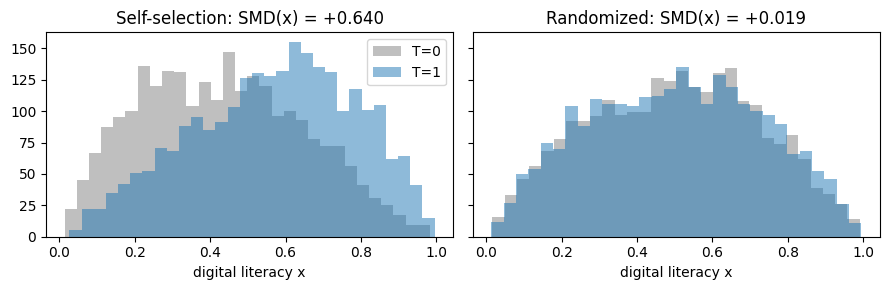

In [6]:
for t_col, label in [('T_self', 'self-selection'), ('T_rand', 'randomized')]:
    t = pop[t_col].values
    att = pop.loc[t == 1, 'tau_i'].mean()
    bias = pop.loc[t == 1, 'y0'].mean() - pop.loc[t == 0, 'y0'].mean()
    print(f"{label:15s} ATT={att:+.4f}  selection bias={bias:+.4f}  ATT+bias={att+bias:+.4f}  naive={naive_diff(pop, t):+.4f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 3), sharey=True)
for ax, t_col, title in zip(axes, ['T_self', 'T_rand'], ['Self-selection', 'Randomized']):
    for arm, c in [(0, 'grey'), (1, 'tab:blue')]:
        ax.hist(pop.loc[pop[t_col] == arm, 'x'], bins=30, alpha=.5, color=c, label=f'T={arm}')
    ax.set_title(f"{title}: SMD(x) = {smd(pop, 'x', t_col):+.3f}"); ax.set_xlabel('digital literacy x')
axes[0].legend(); plt.tight_layout(); plt.show()

## Step 6 - Randomization-inference p-value (1,000 label permutations)
Fisher's sharp null: no effect for *any* unit. Permute the treatment labels the way you assigned them and count how often the permuted difference is at least as extreme as the observed one.

Observed diff = 0.0516, randomization p = 0.000


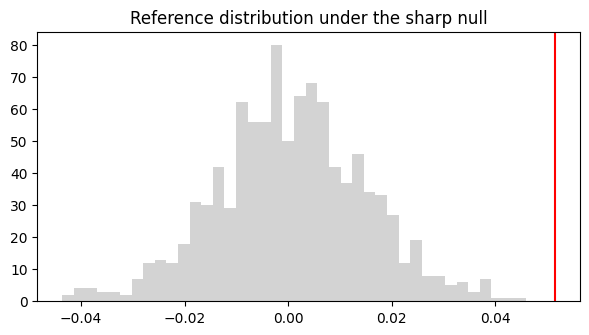

In [7]:
ri = randomization_test(y_rand, pop['T_rand'].values, n_perm=1000, seed=1)
print(f"Observed diff = {ri['observed']:.4f}, randomization p = {ri['p_value']:.3f}")
plt.hist(ri['null_draws'], bins=40, color='lightgrey'); plt.axvline(ri['observed'], color='red')
plt.title('Reference distribution under the sharp null'); plt.show()

## Step 7 - Bias does not shrink with n
Sweep n over {1k, 10k, 100k, 1M}. The self-selection estimate converges to the *biased* value; only the randomized estimate converges to the truth.

         n  self_selection  randomized
0     1000          0.1113      0.0511
1    10000          0.1186      0.0529
2   100000          0.1057      0.0458
3  1000000          0.1055      0.0495


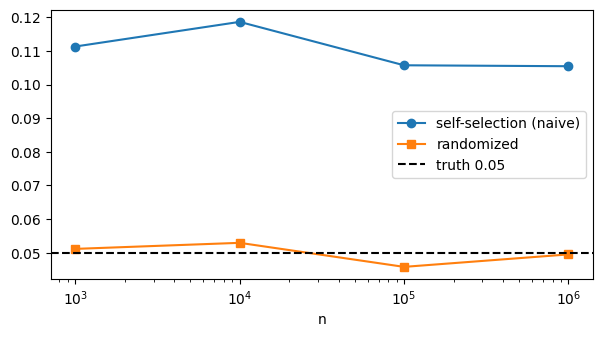

In [8]:
rows = []
for n in [1_000, 10_000, 100_000, 1_000_000]:
    d = simulate_population(n=n, seed=7)
    r = np.random.default_rng(n)
    t_self = r.binomial(1, 0.15 + 0.70 * d['x'])
    t_rand = r.binomial(1, 0.5, size=n)
    rows.append({'n': n, 'self_selection': naive_diff(d, t_self), 'randomized': naive_diff(d, t_rand)})
sweep = pd.DataFrame(rows); print(sweep.round(4))
plt.plot(sweep['n'], sweep['self_selection'], 'o-', label='self-selection (naive)')
plt.plot(sweep['n'], sweep['randomized'], 's-', label='randomized')
plt.axhline(0.05, ls='--', color='k', label='truth 0.05'); plt.xscale('log'); plt.legend(); plt.xlabel('n'); plt.show()

## Step 8 - Three-sentence conclusion for a non-technical manager
Write it in the cell below. It must mention: what the naive number measures, why more data would not have helped, and what design would.

*Your answer:*

...

### Fast finishers
Regress `y` on `T_self` and `x` (`smf.ols('y ~ T + x')`). Does covariate adjustment remove the bias? Partly? Why (think about `age`)? This previews Day 3.